In [1]:
# ============================================================
# Cell 1 — Mount Drive + Imports
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob, re, warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr, pearsonr, mannwhitneyu, norm, gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

Mounted at /content/drive


In [2]:
# ============================================================
# Cell 2 — Global Seed + Paths
# ============================================================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- PBMC paths ---
PBMC_BASE      = '/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset'
PBMC_REV_DOCS  = PBMC_BASE + '/Reverse GeneExpression Required Docs'
PBMC_REAL_DIR  = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Dataset/Real PBMC dataset'
PBMC_SYN_DIR   = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Dataset/Synthetic PBMC dataset'

# --- PDO paths ---
PDO_BASE       = '/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April'
PDO_REV_DOCS   = PDO_BASE + '/Reverse Calculation Related doc'
PDO_REAL_DIR   = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Dataset/Real PDO dataset'
PDO_SYN_DIR    = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Dataset/Synthetic PDO dataset'

# --- Results / plots ---
RESULTS_DIR    = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Metrics_Pipeline_Results'
PLOT_DIR       = RESULTS_DIR + '/Plots'

for d in [PBMC_SYN_DIR, PDO_SYN_DIR, RESULTS_DIR, PLOT_DIR,
          RESULTS_DIR + '/PBMC/SynCellNet',
          RESULTS_DIR + '/PBMC/SynCellNet_Copula',
          RESULTS_DIR + '/PDO/SynCellNet',
          RESULTS_DIR + '/PDO/SynCellNet_Copula']:
    os.makedirs(d, exist_ok=True)

print("Paths ready. SEED =", SEED)

Paths ready. SEED = 42


In [3]:
# ============================================================
# Cell 3 — Load Real Data (PBMC)
# ============================================================
print("="*60)
print("PBMC — Loading real data")
print("="*60)

b_real_gmap   = np.load(PBMC_BASE + '/b_Class_genomap.npy').astype(np.float32)
mono_real_gmap = np.load(PBMC_BASE + '/mono_Class_genomap.npy').astype(np.float32)
if b_real_gmap.ndim == 3:   b_real_gmap   = b_real_gmap[...,   np.newaxis]
if mono_real_gmap.ndim == 3: mono_real_gmap = mono_real_gmap[..., np.newaxis]

stacked_pbmc = np.vstack([b_real_gmap, mono_real_gmap])
PBMC_MIN = float(stacked_pbmc.min())
PBMC_MAX = float(stacked_pbmc.max())
print(f"B genomap:    {b_real_gmap.shape}")
print(f"Mono genomap: {mono_real_gmap.shape}")
print(f"_MIN={PBMC_MIN:.6f} | _MAX={PBMC_MAX:.6f}")

T_b        = np.load(PBMC_REV_DOCS + '/transformation_matrix_T_b_class.npy')
T_mono     = np.load(PBMC_REV_DOCS + '/transformation_matrix_T_mono_class.npy')
means_b    = np.load(PBMC_REV_DOCS + '/original_means_b_class.npy')
means_mono = np.load(PBMC_REV_DOCS + '/original_means_mono_class.npy')
stds_b     = np.load(PBMC_REV_DOCS + '/original_stds_b_class.npy')
stds_mono  = np.load(PBMC_REV_DOCS + '/original_stds_mono_class.npy')

PBMC_NUM_GENES      = T_b.shape[1]
PBMC_TOTAL_GRIDPT   = 40 * 40
print(f"num_genes={PBMC_NUM_GENES} | totalGridPoint={PBMC_TOTAL_GRIDPT}")

real_b_expr    = pd.read_csv(PBMC_REAL_DIR + '/b_Class_dataset.csv',    header=None).values.astype(np.float32)
real_mono_expr = pd.read_csv(PBMC_REAL_DIR + '/mono_Class_dataset.csv', header=None).values.astype(np.float32)
print(f"Real B expr:    {real_b_expr.shape}")
print(f"Real Mono expr: {real_mono_expr.shape}")

PBMC — Loading real data
B genomap:    (1186, 40, 40, 1)
Mono genomap: (1186, 40, 40, 1)
_MIN=-2.464965 | _MAX=34.409313
num_genes=1600 | totalGridPoint=1600
Real B expr:    (1186, 1600)
Real Mono expr: (1186, 1600)


In [14]:
# ============================================================
# Cell 4 — Load Real Data (PDO)  ← CORRECTED PATH
# ============================================================
print("="*60)
print("PDO — Loading real data")
print("="*60)

low_real_gmap  = np.load(PDO_BASE + '/Real_Low_genomap.npy').astype(np.float32)
high_real_gmap = np.load(PDO_BASE + '/Real_High_genomap.npy').astype(np.float32)
if low_real_gmap.ndim == 3:  low_real_gmap  = low_real_gmap[...,  np.newaxis]
if high_real_gmap.ndim == 3: high_real_gmap = high_real_gmap[..., np.newaxis]

stacked_pdo = np.vstack([low_real_gmap, high_real_gmap])
PDO_MIN = float(stacked_pdo.min())
PDO_MAX = float(stacked_pdo.max())
print(f"Low genomap:  {low_real_gmap.shape}")
print(f"High genomap: {high_real_gmap.shape}")
print(f"_MIN={PDO_MIN:.6f} | _MAX={PDO_MAX:.6f}")

T_low      = np.load(PDO_REV_DOCS + '/transformation_matrix_T_Low_class.npy')
T_high     = np.load(PDO_REV_DOCS + '/transformation_matrix_T_High_class.npy')
means_low  = np.load(PDO_REV_DOCS + '/original_means_Low_class.npy')
means_high = np.load(PDO_REV_DOCS + '/original_means_High_class.npy')
stds_low   = np.load(PDO_REV_DOCS + '/original_stds_Low_class.npy')
stds_high  = np.load(PDO_REV_DOCS + '/original_stds_High_class.npy')

PDO_NUM_GENES    = T_low.shape[1]
PDO_TOTAL_GRIDPT = 40 * 40
print(f"num_genes={PDO_NUM_GENES} | totalGridPoint={PDO_TOTAL_GRIDPT}")

# Real gene expression CSVs — lives in PDO_BASE, not in the 16. folder
real_low_expr  = pd.read_csv(PDO_BASE + '/3. Differential_Low_Raw_Finalized.csv',
                              header=None).values.astype(np.float32)
real_high_expr = pd.read_csv(PDO_BASE + '/3. Stem_High_Raw_Finalized.csv',
                              header=None).values.astype(np.float32)
print(f"Real Low expr:  {real_low_expr.shape}")
print(f"Real High expr: {real_high_expr.shape}")

PDO — Loading real data
Low genomap:  (1415, 40, 40, 1)
High genomap: (1415, 40, 40, 1)
_MIN=-0.738665 | _MAX=37.589901
num_genes=1600 | totalGridPoint=1600
Real Low expr:  (1415, 1600)
Real High expr: (1415, 1600)


In [5]:
# ============================================================
# Cell 5 — Load Generators
# ============================================================

print("Loading PBMC generator...")
pbmc_generator = tf.keras.models.load_model(PBMC_BASE + '/generator.h5')
print("  PBMC generator loaded.")

def load_latest_pdo_generator():
    files = glob.glob(PDO_BASE + '/Generator Model/generator_Epoch-*.h5')
    if not files:
        print("  No checkpoint found, loading generator.h5")
        return tf.keras.models.load_model(PDO_BASE + '/generator.h5')
    epochs  = [int(re.search(r'Epoch-(\d+)', f).group(1)) for f in files]
    latest  = max(epochs)
    path    = PDO_BASE + f'/Generator Model/generator_Epoch-{latest}.h5'
    print(f"  Loading PDO generator from epoch {latest}: {path}")
    return tf.keras.models.load_model(path)

print("Loading PDO generator...")
pdo_generator = load_latest_pdo_generator()
print("  PDO generator loaded.")

Loading PBMC generator...


  PBMC generator loaded.
Loading PDO generator...
  Loading PDO generator from epoch 2995: /content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Generator Model/generator_Epoch-2995.h5


  PDO generator loaded.


In [6]:
# ============================================================
# Cell 5b — Compile Generators (silences "no training config" warning)
# Loss and optimizer extracted from 2_cWGAN__Ali_sent_it_Dec_4 &
# 3_cWGAN_for_cancer_27_2_25 — both use identical settings.
# ============================================================

def generator_loss(fake_img):
    """Wasserstein generator loss (same as training)."""
    return -tf.reduce_mean(fake_img)

_g_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5, beta_2=0.9)

pbmc_generator.compile(optimizer=_g_optimizer, loss=generator_loss)
pdo_generator.compile( optimizer=_g_optimizer, loss=generator_loss)

print("Generators compiled. WARNING suppressed.")

Generators compiled. WARNING suppressed.


In [7]:
# ============================================================
# Cell 6 — Generate Synthetic Genomaps (seeded)
# ============================================================
LATENT_DIM = 128

def generate_genomaps(generator, n_samples, label, latent_dim=128,
                       batch_size=64, seed=SEED):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    noise  = tf.random.normal(shape=(n_samples, latent_dim), seed=seed)
    labels = np.full((n_samples, 1), label, dtype=np.float32)
    return generator.predict([noise, labels], batch_size=batch_size)

# --- PBMC ---
print("Generating PBMC synthetic genomaps (seed={})...".format(SEED))
n_b    = b_real_gmap.shape[0]
n_mono = mono_real_gmap.shape[0]

syn_b_tanh    = generate_genomaps(pbmc_generator, n_b,    label=-0.5, seed=SEED)
syn_mono_tanh = generate_genomaps(pbmc_generator, n_mono, label= 0.5, seed=SEED + 1)
print(f"  syn_b:    {syn_b_tanh.shape}  range=[{syn_b_tanh.min():.3f}, {syn_b_tanh.max():.3f}]")
print(f"  syn_mono: {syn_mono_tanh.shape} range=[{syn_mono_tanh.min():.3f}, {syn_mono_tanh.max():.3f}]")

# --- PDO ---
print("\nGenerating PDO synthetic genomaps (seed={})...".format(SEED))
n_low  = low_real_gmap.shape[0]
n_high = high_real_gmap.shape[0]

syn_low_tanh  = generate_genomaps(pdo_generator, n_low,  label=-0.5, seed=SEED)
syn_high_tanh = generate_genomaps(pdo_generator, n_high, label= 0.5, seed=SEED + 1)
print(f"  syn_low:  {syn_low_tanh.shape}  range=[{syn_low_tanh.min():.3f}, {syn_low_tanh.max():.3f}]")
print(f"  syn_high: {syn_high_tanh.shape} range=[{syn_high_tanh.min():.3f}, {syn_high_tanh.max():.3f}]")

Generating PBMC synthetic genomaps (seed=42)...
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
  syn_b:    (1186, 40, 40, 1)  range=[-0.974, 0.743]
  syn_mono: (1186, 40, 40, 1) range=[-0.964, 0.561]

Generating PDO synthetic genomaps (seed=42)...
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
  syn_low:  (1415, 40, 40, 1)  range=[-0.998, 0.999]
  syn_high: (1415, 40, 40, 1) range=[-0.998, 0.997]


In [8]:
# ============================================================
# Cell 7 — Shared Utility Functions
# ============================================================

def reverse_minmax(syn_tanh, _min, _max):
    return ((syn_tanh + 1) * (_max - _min) / 2) + _min


def reverse_pseudoinverse(syn_orig_scale, T, means, stds, num_genes, total_gp):
    """
    SynCellNet — Option B (Pseudo-inverse)
    Recovers gene expression from genomap using the Moore-Penrose pseudo-inverse.
    """
    n_samples   = syn_orig_scale.shape[0]
    projMat     = T * total_gp
    projMat_inv = np.linalg.pinv(projMat)

    projM = np.zeros((n_samples, num_genes), dtype=np.float32)
    for i in range(n_samples):
        ex = syn_orig_scale[i, :, :, 0].flatten(order='F')
        projM[i, :] = ex[:num_genes]

    X_norm = np.matmul(projM, projMat_inv)
    return ((X_norm * stds) + means).astype(np.float32)


def make_positive_definite(R):
    """Ensure correlation matrix is positive definite via eigenvalue clipping."""
    eigvals, eigvecs = np.linalg.eigh(R)
    eigvals = np.clip(eigvals, 1e-6, None)
    return eigvecs @ np.diag(eigvals) @ eigvecs.T


def apply_gaussian_copula(syn_expr, real_expr, seed=SEED):
    """
    SynCellNet + Copula post-processing.
    Imposes real data correlation structure while preserving marginal distributions.

    Steps:
      1. Rank-transform synthetic → uniform pseudo-observations
      2. Map uniform → Gaussian via norm.ppf
      3. Impose real correlation via Cholesky decomposition
      4. Map back to real marginals via quantile matching
    """
    np.random.seed(seed)
    n_syn, n_genes = syn_expr.shape

    # Step 1: rank-transform
    ranks = np.argsort(np.argsort(syn_expr, axis=0), axis=0)
    u     = (ranks + 1) / (n_syn + 1)                      # (n_syn, n_genes)

    # Step 2: uniform → Gaussian
    z = norm.ppf(u)                                          # (n_syn, n_genes)

    # Step 3: real correlation matrix + Cholesky
    R_real = np.corrcoef(real_expr.T)
    R_real = make_positive_definite(R_real + np.eye(n_genes) * 1e-4)
    L      = np.linalg.cholesky(R_real)

    z = (z - z.mean(axis=0)) / (z.std(axis=0) + 1e-8)
    z_corr = z @ L.T                                         # impose correlation

    # Step 4: map back to real marginals
    u_corr = np.clip(norm.cdf(z_corr), 0.001, 0.999)
    syn_copula = np.zeros_like(syn_expr)
    for g in range(n_genes):
        syn_copula[:, g] = np.quantile(real_expr[:, g], u_corr[:, g])

    return syn_copula.astype(np.float32)

In [9]:
# ============================================================
# Cell 8 — Method 1: SynCellNet (Pseudo-inverse) — PBMC
# ============================================================
print("="*60)
print("PBMC — SynCellNet (Pseudo-inverse)")
print("="*60)

syn_b_orig    = reverse_minmax(syn_b_tanh,    PBMC_MIN, PBMC_MAX)
syn_mono_orig = reverse_minmax(syn_mono_tanh, PBMC_MIN, PBMC_MAX)

pbmc_syn_b_pseudoinv    = reverse_pseudoinverse(syn_b_orig,    T_b,    means_b,    stds_b,    PBMC_NUM_GENES, PBMC_TOTAL_GRIDPT)
pbmc_syn_mono_pseudoinv = reverse_pseudoinverse(syn_mono_orig, T_mono, means_mono, stds_mono, PBMC_NUM_GENES, PBMC_TOTAL_GRIDPT)

print(f"syn_b:    {pbmc_syn_b_pseudoinv.shape}  range=[{pbmc_syn_b_pseudoinv.min():.3f}, {pbmc_syn_b_pseudoinv.max():.3f}]")
print(f"syn_mono: {pbmc_syn_mono_pseudoinv.shape} range=[{pbmc_syn_mono_pseudoinv.min():.3f}, {pbmc_syn_mono_pseudoinv.max():.3f}]")

pd.DataFrame(pbmc_syn_b_pseudoinv).to_csv(   PBMC_SYN_DIR + '/syncellnet_b_expression.csv',    index=False, header=False, float_format='%.6f')
pd.DataFrame(pbmc_syn_mono_pseudoinv).to_csv(PBMC_SYN_DIR + '/syncellnet_mono_expression.csv', index=False, header=False, float_format='%.6f')
print("Saved: syncellnet_b_expression.csv | syncellnet_mono_expression.csv")

PBMC — SynCellNet (Pseudo-inverse)
syn_b:    (1186, 1600)  range=[-2.016, 48.297]
syn_mono: (1186, 1600) range=[-2.499, 131.593]
Saved: syncellnet_b_expression.csv | syncellnet_mono_expression.csv


In [10]:
# ============================================================
# Cell 9 — Method 2: SynCellNet + Copula — PBMC
# ============================================================
print("="*60)
print("PBMC — SynCellNet + Copula")
print("="*60)

pbmc_syn_b_copula    = apply_gaussian_copula(pbmc_syn_b_pseudoinv,    real_b_expr,    seed=SEED)
pbmc_syn_mono_copula = apply_gaussian_copula(pbmc_syn_mono_pseudoinv, real_mono_expr, seed=SEED + 1)

print(f"syn_b copula:    {pbmc_syn_b_copula.shape}")
print(f"syn_mono copula: {pbmc_syn_mono_copula.shape}")

var_b    = pbmc_syn_b_copula.var(axis=0).mean()    / real_b_expr.var(axis=0).mean()
var_mono = pbmc_syn_mono_copula.var(axis=0).mean() / real_mono_expr.var(axis=0).mean()
print(f"Variance ratio (copula/real) — B: {var_b:.4f} | Mono: {var_mono:.4f}  [1.0 = ideal]")

pd.DataFrame(pbmc_syn_b_copula).to_csv(   PBMC_SYN_DIR + '/copula_b_expression.csv',    index=False, header=False, float_format='%.6f')
pd.DataFrame(pbmc_syn_mono_copula).to_csv(PBMC_SYN_DIR + '/copula_mono_expression.csv', index=False, header=False, float_format='%.6f')
print("Saved: copula_b_expression.csv | copula_mono_expression.csv")

PBMC — SynCellNet + Copula
syn_b copula:    (1186, 1600)
syn_mono copula: (1186, 1600)
Variance ratio (copula/real) — B: 0.9582 | Mono: 1.0139  [1.0 = ideal]
Saved: copula_b_expression.csv | copula_mono_expression.csv


In [11]:
# ============================================================
# Cell 10 — Method 1: SynCellNet (Pseudo-inverse) — PDO
# ============================================================
print("="*60)
print("PDO — SynCellNet (Pseudo-inverse)")
print("="*60)

syn_low_orig  = reverse_minmax(syn_low_tanh,  PDO_MIN, PDO_MAX)
syn_high_orig = reverse_minmax(syn_high_tanh, PDO_MIN, PDO_MAX)

pdo_syn_low_pseudoinv  = reverse_pseudoinverse(syn_low_orig,  T_low,  means_low,  stds_low,  PDO_NUM_GENES, PDO_TOTAL_GRIDPT)
pdo_syn_high_pseudoinv = reverse_pseudoinverse(syn_high_orig, T_high, means_high, stds_high, PDO_NUM_GENES, PDO_TOTAL_GRIDPT)

print(f"syn_low:  {pdo_syn_low_pseudoinv.shape}  range=[{pdo_syn_low_pseudoinv.min():.3f}, {pdo_syn_low_pseudoinv.max():.3f}]")
print(f"syn_high: {pdo_syn_high_pseudoinv.shape} range=[{pdo_syn_high_pseudoinv.min():.3f}, {pdo_syn_high_pseudoinv.max():.3f}]")

pd.DataFrame(pdo_syn_low_pseudoinv).to_csv( PDO_SYN_DIR + '/syncellnet_low_expression.csv',  index=False, header=False, float_format='%.6f')
pd.DataFrame(pdo_syn_high_pseudoinv).to_csv(PDO_SYN_DIR + '/syncellnet_high_expression.csv', index=False, header=False, float_format='%.6f')
print("Saved: syncellnet_low_expression.csv | syncellnet_high_expression.csv")

PDO — SynCellNet (Pseudo-inverse)
syn_low:  (1415, 1600)  range=[-0.223, 18.486]
syn_high: (1415, 1600) range=[-0.590, 47.676]
Saved: syncellnet_low_expression.csv | syncellnet_high_expression.csv


In [15]:
# ============================================================
# Cell 11 — Method 2: SynCellNet + Copula — PDO
# ============================================================
print("="*60)
print("PDO — SynCellNet + Copula")
print("="*60)

pdo_syn_low_copula  = apply_gaussian_copula(pdo_syn_low_pseudoinv,  real_low_expr,  seed=SEED)
pdo_syn_high_copula = apply_gaussian_copula(pdo_syn_high_pseudoinv, real_high_expr, seed=SEED + 1)

print(f"syn_low copula:  {pdo_syn_low_copula.shape}")
print(f"syn_high copula: {pdo_syn_high_copula.shape}")

var_low  = pdo_syn_low_copula.var(axis=0).mean()  / real_low_expr.var(axis=0).mean()
var_high = pdo_syn_high_copula.var(axis=0).mean() / real_high_expr.var(axis=0).mean()
print(f"Variance ratio (copula/real) — Low: {var_low:.4f} | High: {var_high:.4f}  [1.0 = ideal]")
print("NOTE: If Low var ratio < 0.7, copula may be collapsing sparse genes — inspect before reporting.")

pd.DataFrame(pdo_syn_low_copula).to_csv( PDO_SYN_DIR + '/copula_low_expression.csv',  index=False, header=False, float_format='%.6f')
pd.DataFrame(pdo_syn_high_copula).to_csv(PDO_SYN_DIR + '/copula_high_expression.csv', index=False, header=False, float_format='%.6f')
print("Saved: copula_low_expression.csv | copula_high_expression.csv")

PDO — SynCellNet + Copula
syn_low copula:  (1415, 1600)
syn_high copula: (1415, 1600)
Variance ratio (copula/real) — Low: 0.5615 | High: 2.4813  [1.0 = ideal]
NOTE: If Low var ratio < 0.7, copula may be collapsing sparse genes — inspect before reporting.
Saved: copula_low_expression.csv | copula_high_expression.csv


Dimensionality Reduction Plots — PBMC

  PBMC — SynCellNet...
    UMAP...
    t-SNE...


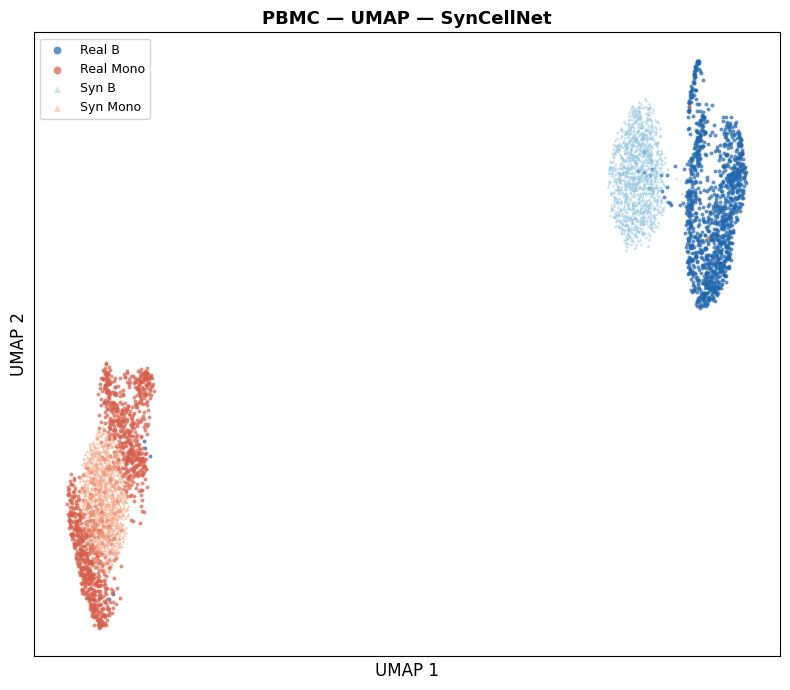

    Saved: PBMC_UMAP_SynCellNet.png


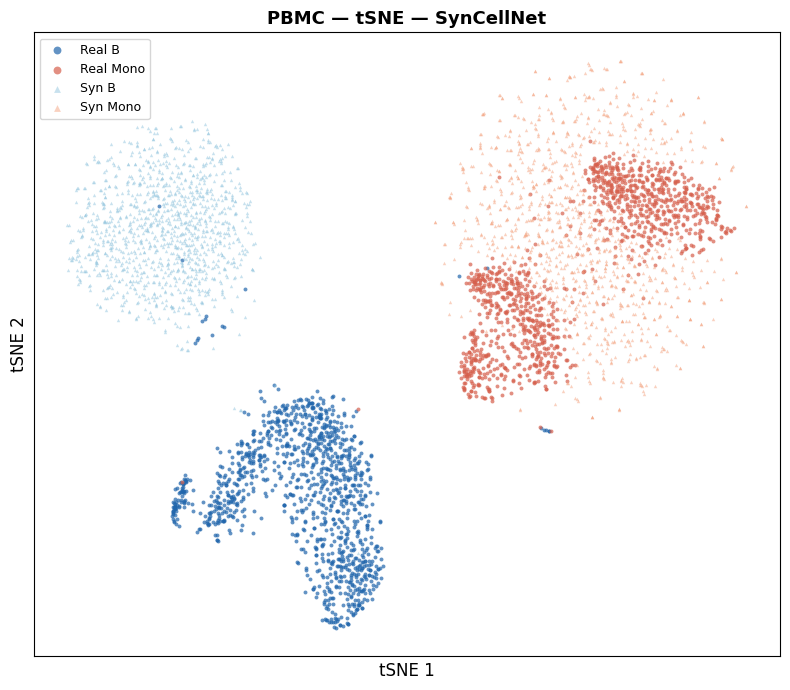

    Saved: PBMC_tSNE_SynCellNet.png

  PBMC — SynCellNet+Copula...
    UMAP...
    t-SNE...


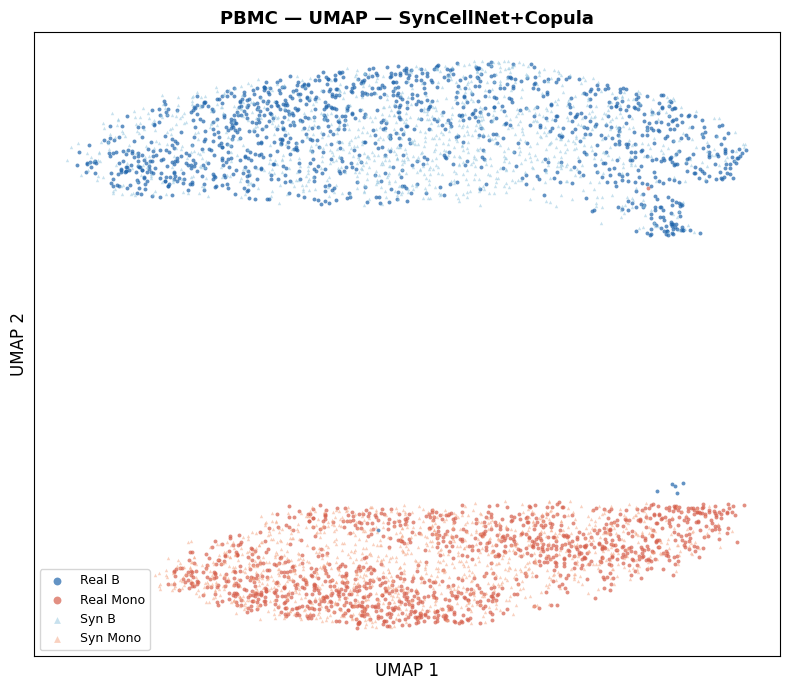

    Saved: PBMC_UMAP_SynCellNet+Copula.png


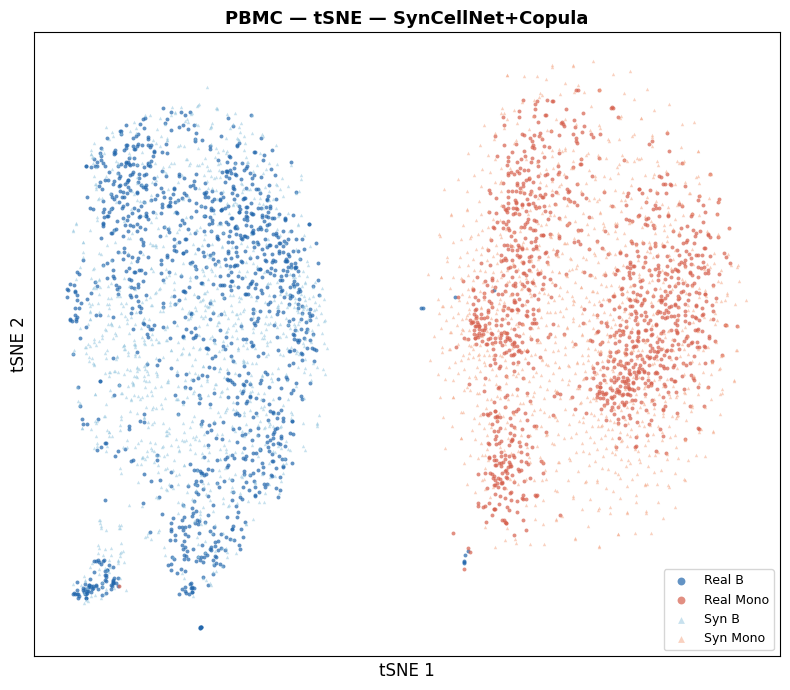

    Saved: PBMC_tSNE_SynCellNet+Copula.png

Dimensionality Reduction Plots — PDO

  PDO — SynCellNet...
    UMAP...
    t-SNE...


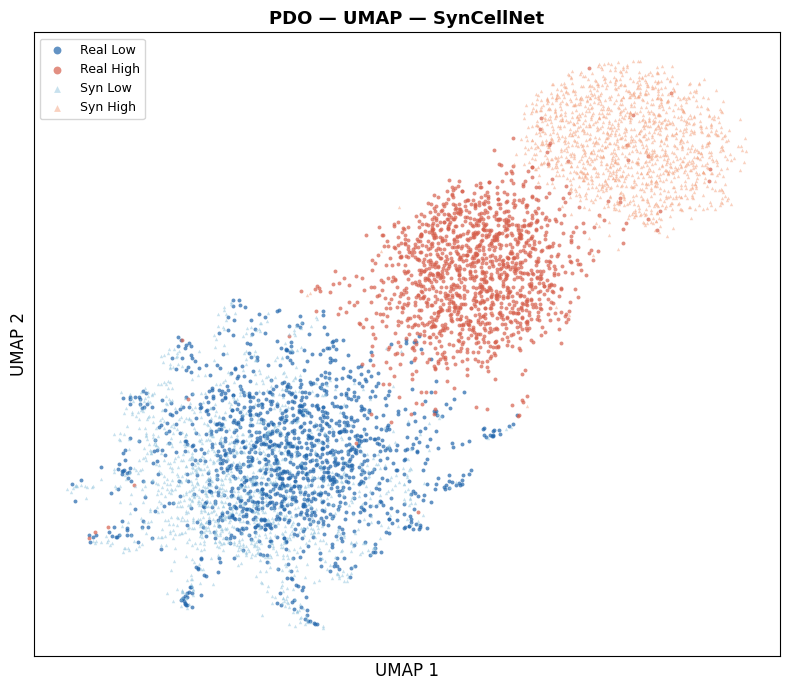

    Saved: PDO_UMAP_SynCellNet.png


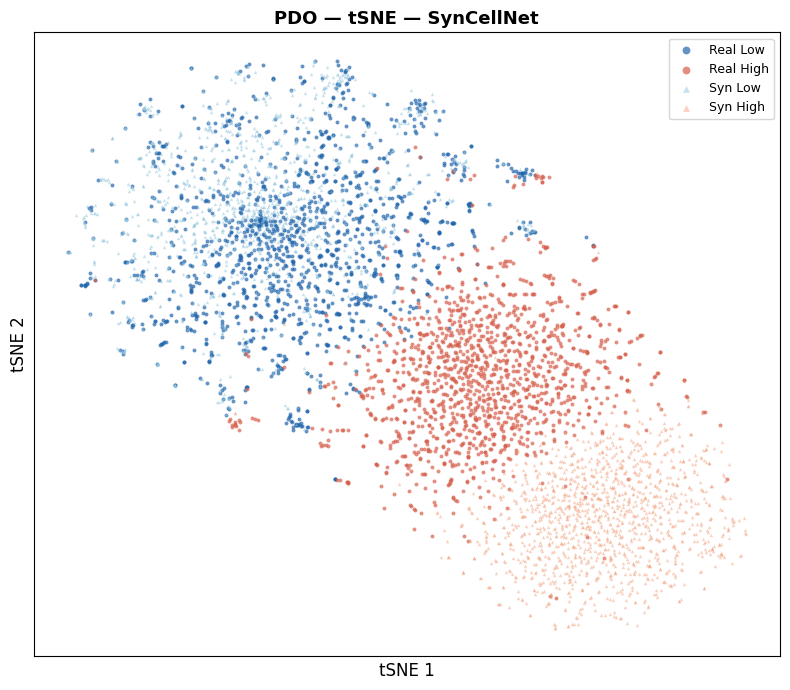

    Saved: PDO_tSNE_SynCellNet.png

  PDO — SynCellNet+Copula...
    UMAP...
    t-SNE...


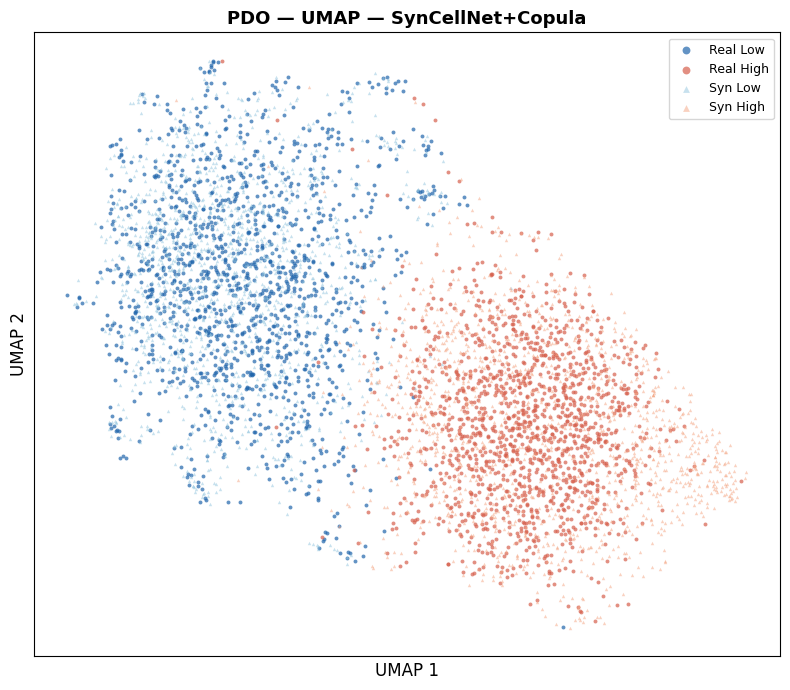

    Saved: PDO_UMAP_SynCellNet+Copula.png


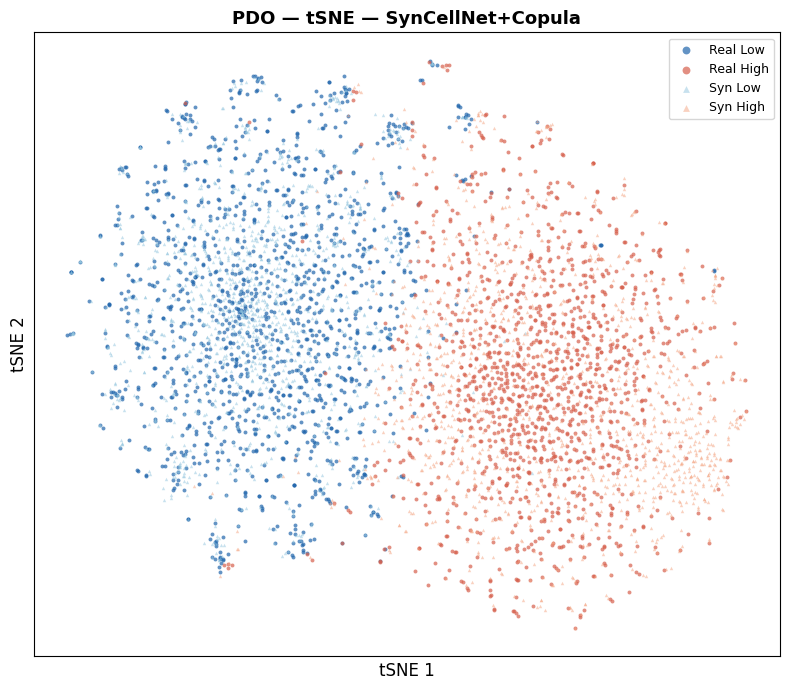

    Saved: PDO_tSNE_SynCellNet+Copula.png

All plots saved to: /content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Metrics_Pipeline_Results/Plots


In [16]:
# ============================================================
# Cell 16 — UMAP + t-SNE: Real vs Synthetic (Before & After Copula)
# ============================================================

def plot_dimensionality_reduction(real_c1, real_c2,
                                   syn_c1_before, syn_c2_before,
                                   syn_c1_after,  syn_c2_after,
                                   label_c1, label_c2,
                                   dataset_name, save_dir,
                                   n_pca=50, seed=SEED):
    colors = {
        f'Real {label_c1}':      '#2166ac',
        f'Real {label_c2}':      '#d6604d',
        f'Syn {label_c1}':       '#92c5de',
        f'Syn {label_c2}':       '#f4a582',
    }

    for condition, syn1, syn2 in [
        ('SynCellNet',         syn_c1_before, syn_c2_before),
        ('SynCellNet+Copula',  syn_c1_after,  syn_c2_after)
    ]:
        print(f"\n  {dataset_name} — {condition}...")

        X = np.vstack([real_c1, real_c2, syn1, syn2])
        group_labels = np.array(
            [f'Real {label_c1}'] * len(real_c1) +
            [f'Real {label_c2}'] * len(real_c2) +
            [f'Syn {label_c1}']  * len(syn1)    +
            [f'Syn {label_c2}']  * len(syn2)
        )

        X_scaled = StandardScaler().fit_transform(X)
        n_comp   = min(n_pca, X_scaled.shape[0] - 1, X_scaled.shape[1])
        X_pca    = PCA(n_components=n_comp, random_state=seed).fit_transform(X_scaled)

        print("    UMAP...")
        X_umap = umap.UMAP(n_neighbors=30, min_dist=0.3,
                            n_components=2, random_state=seed).fit_transform(X_pca)

        print("    t-SNE...")
        X_tsne = TSNE(n_components=2, perplexity=40,
                      random_state=seed, n_iter=1000).fit_transform(X_pca)

        for embedding, method in [(X_umap, 'UMAP'), (X_tsne, 'tSNE')]:
            fig, ax = plt.subplots(figsize=(8, 7))
            for lbl in colors:
                mask   = group_labels == lbl
                marker = 'o' if 'Real' in lbl else '^'
                alpha  = 0.7 if 'Real' in lbl else 0.5
                size   = 8   if 'Real' in lbl else 6
                ax.scatter(embedding[mask, 0], embedding[mask, 1],
                           c=colors[lbl], label=lbl,
                           marker=marker, alpha=alpha, s=size, linewidths=0)
            ax.set_title(f'{dataset_name} — {method} — {condition}',
                         fontsize=13, fontweight='bold')
            ax.set_xlabel(f'{method} 1', fontsize=12)
            ax.set_ylabel(f'{method} 2', fontsize=12)
            ax.legend(fontsize=9, markerscale=2, framealpha=0.8)
            ax.set_xticks([]); ax.set_yticks([])
            plt.tight_layout()
            fname = f'{dataset_name}_{method}_{condition}.png'
            plt.savefig(f'{save_dir}/{fname}', dpi=150, bbox_inches='tight')
            plt.show()
            print(f"    Saved: {fname}")


print("="*60)
print("Dimensionality Reduction Plots — PBMC")
print("="*60)
plot_dimensionality_reduction(
    real_b_expr,    real_mono_expr,
    pbmc_syn_b_pseudoinv,   pbmc_syn_mono_pseudoinv,
    pbmc_syn_b_copula,      pbmc_syn_mono_copula,
    label_c1='B', label_c2='Mono',
    dataset_name='PBMC', save_dir=PLOT_DIR, seed=SEED
)

print("\n" + "="*60)
print("Dimensionality Reduction Plots — PDO")
print("="*60)
plot_dimensionality_reduction(
    real_low_expr,   real_high_expr,
    pdo_syn_low_pseudoinv,  pdo_syn_high_pseudoinv,
    pdo_syn_low_copula,     pdo_syn_high_copula,
    label_c1='Low', label_c2='High',
    dataset_name='PDO', save_dir=PLOT_DIR, seed=SEED
)

print(f"\nAll plots saved to: {PLOT_DIR}")

In [17]:
# ============================================================
# Cell 12 — Scale Stability Evaluation
# Replaces the single-shot evaluate_biological_fidelity calls.
# Runs 3 key metrics at n_cells = [500, 1000, 2000] per class
# for both methods and both datasets, then plots stability curves.
#
# Metrics (from metrics_analysis_v3):
#   mean_corr — Pearson r of per-gene mean expression (real vs syn)
#   avg_KS    — mean KS statistic across all genes (lower = better)
#   DE_F1     — F1 score for DE gene recovery (FDR-BH Wilcoxon)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ks_2samp, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

SEED       = 42
SCALES     = [500, 1000, 2000]          # cells per class
METHODS_2  = ['SynCellNet', 'SynCellNet+Copula']
SAVE_DIR   = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Metrics_Pipeline_Results'
os.makedirs(SAVE_DIR, exist_ok=True)

METHOD_COLORS = {
    'SynCellNet':          'royalblue',
    'SynCellNet+Copula':   'mediumseagreen',
}

# ============================================================
# Helper: compute the 3 scale metrics for one (real, syn) pair
# ============================================================

def compute_mean_corr(real, syn):
    """Pearson r between per-gene mean expression vectors."""
    r, _ = stats.pearsonr(real.mean(axis=0), syn.mean(axis=0))
    return float(r)


def compute_avg_ks(real, syn):
    """Mean KS statistic across all genes (lower = better)."""
    n_genes = real.shape[1]
    return float(np.mean([ks_2samp(real[:, g], syn[:, g]).statistic
                          for g in range(n_genes)]))


def compute_de_f1(real_c1, real_c2, syn_c1, syn_c2, alpha=0.05):
    """
    DE F1: F1 score for recovering DE genes identified in real data.
    Reference DE set is always computed from the FULL real data
    (not subsampled) so the target is stable across scales.
    """
    n_genes = min(real_c1.shape[1], real_c2.shape[1],
                  syn_c1.shape[1],  syn_c2.shape[1])
    real_c1 = real_c1[:, :n_genes];  real_c2 = real_c2[:, :n_genes]
    syn_c1  = syn_c1[:,  :n_genes];  syn_c2  = syn_c2[:,  :n_genes]

    def de_mask(X0, X1):
        pvals = [mannwhitneyu(X0[:, g], X1[:, g],
                              alternative='two-sided')[1]
                 for g in range(n_genes)]
        _, padj, _, _ = multipletests(pvals, method='fdr_bh')
        return padj < alpha

    de_real = de_mask(real_c1, real_c2)
    de_syn  = de_mask(syn_c1,  syn_c2)
    n_real  = de_real.sum()
    n_syn   = de_syn.sum()

    if n_real == 0 or n_syn == 0:
        return 0.0

    overlap   = (de_real & de_syn).sum()
    precision = overlap / n_syn
    recall    = overlap / n_real
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    return float(f1)


def subsample(X, n, seed):
    """Randomly subsample n rows from X (replace=True if n > len)."""
    np.random.seed(seed)
    idx = np.random.choice(len(X), size=min(n, len(X)), replace=False)
    return X[idx]


# ============================================================
# Scale evaluation loop — one dataset at a time
# ============================================================

def run_scale_evaluation(dataset_name,
                          real_c1_full, real_c2_full,
                          syn_dict,              # {'SynCellNet': (syn_c1, syn_c2), ...}
                          label_c1, label_c2,
                          scales=SCALES, seed=SEED):
    """
    For each method and each scale, subsample synthetic data and
    compute mean_corr, avg_KS, DE_F1 averaged across both classes.

    real_c1_full / real_c2_full are always used at full size as reference.
    The real data is also subsampled to the same n for mean_corr and avg_KS
    so the comparison is fair at each scale.
    """
    records = []

    print(f"\n{'='*65}")
    print(f"Scale Stability — {dataset_name}  "
          f"(classes: {label_c1}, {label_c2})")
    print(f"{'='*65}")
    print(f"{'Method':<22} {'Scale':>6}  "
          f"{'mean_corr_C1':>13} {'mean_corr_C2':>13}  "
          f"{'avg_KS_C1':>10} {'avg_KS_C2':>10}  "
          f"{'DE_F1':>7}")
    print("-"*95)

    for method in METHODS_2:
        syn_c1_full, syn_c2_full = syn_dict[method]

        for n in scales:
            # Subsample both real and synthetic to n cells
            r1 = subsample(real_c1_full, n, seed)
            r2 = subsample(real_c2_full, n, seed + 1)
            s1 = subsample(syn_c1_full,  n, seed + 2)
            s2 = subsample(syn_c2_full,  n, seed + 3)

            mc1  = compute_mean_corr(r1, s1)
            mc2  = compute_mean_corr(r2, s2)
            ks1  = compute_avg_ks(r1, s1)
            ks2  = compute_avg_ks(r2, s2)
            # DE F1: real reference = full real data, syn = subsampled
            f1   = compute_de_f1(real_c1_full, real_c2_full, s1, s2)

            records.append({
                'dataset'       : dataset_name,
                'method'        : method,
                'n_cells'       : n,
                f'mean_corr_{label_c1}' : round(mc1, 4),
                f'mean_corr_{label_c2}' : round(mc2, 4),
                f'avg_KS_{label_c1}'    : round(ks1, 4),
                f'avg_KS_{label_c2}'    : round(ks2, 4),
                'DE_F1'         : round(f1, 4),
            })

            print(f"  {method:<20} {n:>6}  "
                  f"{mc1:>13.4f} {mc2:>13.4f}  "
                  f"{ks1:>10.4f} {ks2:>10.4f}  "
                  f"{f1:>7.4f}")

    return pd.DataFrame(records)


# ============================================================
# Run for PBMC
# ============================================================
pbmc_syn_dict = {
    'SynCellNet':        (pbmc_syn_b_pseudoinv,  pbmc_syn_mono_pseudoinv),
    'SynCellNet+Copula': (pbmc_syn_b_copula,     pbmc_syn_mono_copula),
}

df_pbmc_scale = run_scale_evaluation(
    dataset_name='PBMC',
    real_c1_full=real_b_expr,
    real_c2_full=real_mono_expr,
    syn_dict=pbmc_syn_dict,
    label_c1='B', label_c2='Mono',
)

# ============================================================
# Run for PDO
# ============================================================
pdo_syn_dict = {
    'SynCellNet':        (pdo_syn_low_pseudoinv,  pdo_syn_high_pseudoinv),
    'SynCellNet+Copula': (pdo_syn_low_copula,     pdo_syn_high_copula),
}

df_pdo_scale = run_scale_evaluation(
    dataset_name='PDO',
    real_c1_full=real_low_expr,
    real_c2_full=real_high_expr,
    syn_dict=pdo_syn_dict,
    label_c1='Low', label_c2='High',
)

# ============================================================
# Save CSVs
# ============================================================
df_pbmc_scale.to_csv(SAVE_DIR + '/scale_stability_PBMC.csv', index=False)
df_pdo_scale.to_csv( SAVE_DIR + '/scale_stability_PDO.csv',  index=False)
print(f"\nCSVs saved to: {SAVE_DIR}")


Scale Stability — PBMC  (classes: B, Mono)
Method                  Scale   mean_corr_C1  mean_corr_C2   avg_KS_C1  avg_KS_C2    DE_F1
-----------------------------------------------------------------------------------------------
  SynCellNet              500         0.9830        0.9931      0.5890     0.5535   0.9273
  SynCellNet             1000         0.9849        0.9933      0.5890     0.5521   0.9488
  SynCellNet             2000         0.9849        0.9932      0.5893     0.5519   0.9515
  SynCellNet+Copula       500         0.9982        0.9993      0.0137     0.0184   0.9956
  SynCellNet+Copula      1000         0.9994        0.9997      0.0093     0.0122   0.9984
  SynCellNet+Copula      2000         0.9995        0.9998      0.0082     0.0109   0.9997

Scale Stability — PDO  (classes: Low, High)
Method                  Scale   mean_corr_C1  mean_corr_C2   avg_KS_C1  avg_KS_C2    DE_F1
---------------------------------------------------------------------------------------

In [18]:
# ============================================================
# Cell 14 — Combined Summary Table (both datasets)
# ============================================================
df_all_scale = pd.concat([df_pbmc_scale, df_pdo_scale], ignore_index=True)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("\n" + "="*95)
print("SCALE STABILITY SUMMARY — PBMC + PDO")
print("="*95)
print(df_all_scale.to_string(index=False))

df_all_scale.to_csv(SAVE_DIR + '/scale_stability_combined.csv', index=False)
print(f"\nFull table saved: {SAVE_DIR}/scale_stability_combined.csv")


SCALE STABILITY SUMMARY — PBMC + PDO
dataset            method  n_cells  mean_corr_B  mean_corr_Mono  avg_KS_B  avg_KS_Mono  DE_F1  mean_corr_Low  mean_corr_High  avg_KS_Low  avg_KS_High
   PBMC        SynCellNet      500       0.9830          0.9931    0.5890       0.5535 0.9273            NaN             NaN         NaN          NaN
   PBMC        SynCellNet     1000       0.9849          0.9933    0.5890       0.5521 0.9488            NaN             NaN         NaN          NaN
   PBMC        SynCellNet     2000       0.9849          0.9932    0.5893       0.5519 0.9515            NaN             NaN         NaN          NaN
   PBMC SynCellNet+Copula      500       0.9982          0.9993    0.0137       0.0184 0.9956            NaN             NaN         NaN          NaN
   PBMC SynCellNet+Copula     1000       0.9994          0.9997    0.0093       0.0122 0.9984            NaN             NaN         NaN          NaN
   PBMC SynCellNet+Copula     2000       0.9995          0.999